# 21 — Data Preprocessing: Known Issues for the RCA Agent

This notebook builds a **Known Issues** knowledge base from past corrective-maintenance interventions.

## Pipeline
1. **Fetch** – pull embeddings + metadata from the `cm_interventions_hybrid` Qdrant collection
2. **Cluster** – run HDBSCAN (density-based, auto-selects k) on the embedding space
3. **Represent** – pick the best representative points per cluster (medoid + high-confidence members)
4. **Synthesize** – call an LLM with structured output to produce a `KnownIssue` template per cluster
5. **Store** – upsert each `KnownIssue` into a dedicated `known_issues` Qdrant collection

## Evolutive update (new batches)
When new interventions arrive, the last cell re-runs the *incremental* path:
- Embed new points → search `known_issues` by cosine similarity
- If best match ≥ threshold → LLM decides whether to **merge** into existing issue
- Otherwise → treat as a **new candidate** and synthesize a new `KnownIssue`

## 0 · Imports & Config

In [16]:
import os
import uuid
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dotenv

import hdbscan
import umap

import openai
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance,
    VectorParams,
    PointStruct,
    Filter,
    FieldCondition,
    MatchValue,
)

dotenv.load_dotenv(Path("../").resolve() / ".env")

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
client_oai = openai.OpenAI(api_key=OPENAI_API_KEY)

QDRANT_HOST = "http://localhost:6333"
SOURCE_COLLECTION = "cm_interventions_hybrid"
KNOWN_ISSUES_COLLECTION = "known_issues"
EMBEDDING_MODEL = "text-embedding-3-small"
LLM_MODEL = "gpt-4o-mini"
SIMILARITY_THRESHOLD = 0.75   # cosine similarity to consider merging into an existing issue

qdrant = QdrantClient(QDRANT_HOST)
print("Qdrant collections:", [c.name for c in qdrant.get_collections().collections])

Qdrant collections: ['procedures_hybrid', 'cm_interventions', 'cm_interventions_hybrid', 'known_issues']


## 1 · Fetch Embeddings and Metadata from Qdrant

In [17]:
def scroll_all_points(client: QdrantClient, collection: str, vector_name: str = "text-embedding-3-small"):
    """Page through all points and return (ids, vectors, payloads)."""
    all_ids, all_vectors, all_payloads = [], [], []
    offset = None
    while True:
        records, next_offset = client.scroll(
            collection_name=collection,
            limit=256,
            offset=offset,
            with_payload=True,
            with_vectors=[vector_name],
        )
        for r in records:
            vec = r.vector
            if isinstance(vec, dict):
                vec = vec.get(vector_name)
            if vec is None:
                continue
            all_ids.append(r.id)
            all_vectors.append(vec)
            all_payloads.append(r.payload)
        if next_offset is None:
            break
        offset = next_offset
    return all_ids, np.array(all_vectors, dtype=np.float32), all_payloads


point_ids, embeddings, payloads = scroll_all_points(qdrant, SOURCE_COLLECTION)
print(f"Fetched {len(point_ids)} points  |  embedding dim = {embeddings.shape[1]}")

Fetched 416 points  |  embedding dim = 1536


In [18]:
df = pd.DataFrame(payloads)
df["_qdrant_id"] = point_ids
df.head(3)

,id,date_start,machine,duration_min,summary,embedding_model,created_at,_qdrant_id
0,INT-2025-0126,2025-05-13 16:00,IH-300,60,[FAULT_CODE] H-006\n[EVENT] Ground Fault Detec...,text-embedding-3-small,2026-05-04T19:18:57.586129,003f3cd5-03b7-4f4f-a6bf-01769d8f9467
1,INT-2025-0336,2025-01-27 10:00,IH-300,203,[FAULT_CODE] H-006\n[RELATED_INTERVENTION] INT...,text-embedding-3-small,2026-05-04T19:18:57.586129,012cc6ec-1dbb-4512-8abd-74350a051a93
2,INT-2025-0398,2025-05-21 06:00,HX-200,177,[FAULT_CODE] E-002\n[EVENT] High Oil Temperatu...,text-embedding-3-small,2026-05-04T19:18:57.586129,027922e4-fdd1-4b56-afa9-c9ee781b4f80


## 2 · UMAP Dimensionality Reduction (for HDBSCAN + Visualisation)

In [19]:
# Reduce to 10D for clustering (keeps density structure better than 2D)
reducer_cluster = umap.UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,          # tighter clusters for HDBSCAN
    metric="cosine",
    random_state=42,
)
emb_10d = reducer_cluster.fit_transform(embeddings)
print("10-D shape:", emb_10d.shape)

# 2-D for plotting only
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
emb_2d = reducer_2d.fit_transform(embeddings)
print("2-D shape:", emb_2d.shape)

/Users/jooaobrum/Library/CloudStorage/GoogleDrive-joao.paulo.brum14@gmail.com/My Drive/Projetos Pessoais/Projetos de Estudo/end2end-ai-engineering-bootcamp/hephaestus-agentic-maintenance/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


10-D shape: (416, 10)


/Users/jooaobrum/Library/CloudStorage/GoogleDrive-joao.paulo.brum14@gmail.com/My Drive/Projetos Pessoais/Projetos de Estudo/end2end-ai-engineering-bootcamp/hephaestus-agentic-maintenance/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2-D shape: (416, 2)


## 3 · HDBSCAN Clustering

In [20]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,       # minimum interventions to form a known issue
    min_samples=3,
    cluster_selection_epsilon=0.0,
    cluster_selection_method="eom",   # Excess of Mass — stable clusters
    metric="euclidean",               # on UMAP-reduced space
    prediction_data=True,             # needed for soft clustering / incremental
)
clusterer.fit(emb_10d)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

df["cluster"] = labels
df["cluster_prob"] = clusterer.probabilities_

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise} / {len(labels)}")
print(df["cluster"].value_counts().rename("count").to_frame())

Clusters found : 41
Noise points   : 4 / 416
         count
cluster       
 5          19
 6          18
 7          18
 29         15
 28         14
 23         14
 38         13
 36         13
 32         13
 30         13
 18         12
 37         12
 31         12
 40         11
 9          11
 13         11
 17         10
 11          9
 12          9
 33          9
 26          9
 14          9
 25          9
 39          9
 19          9
 34          8
 1           8
 27          8
 24          8
 3           8
 20          7
 22          7
 2           7
 8           7
 35          7
 4           7
 16          7
 15          6
 10          6
 21          5
 0           5
-1           4


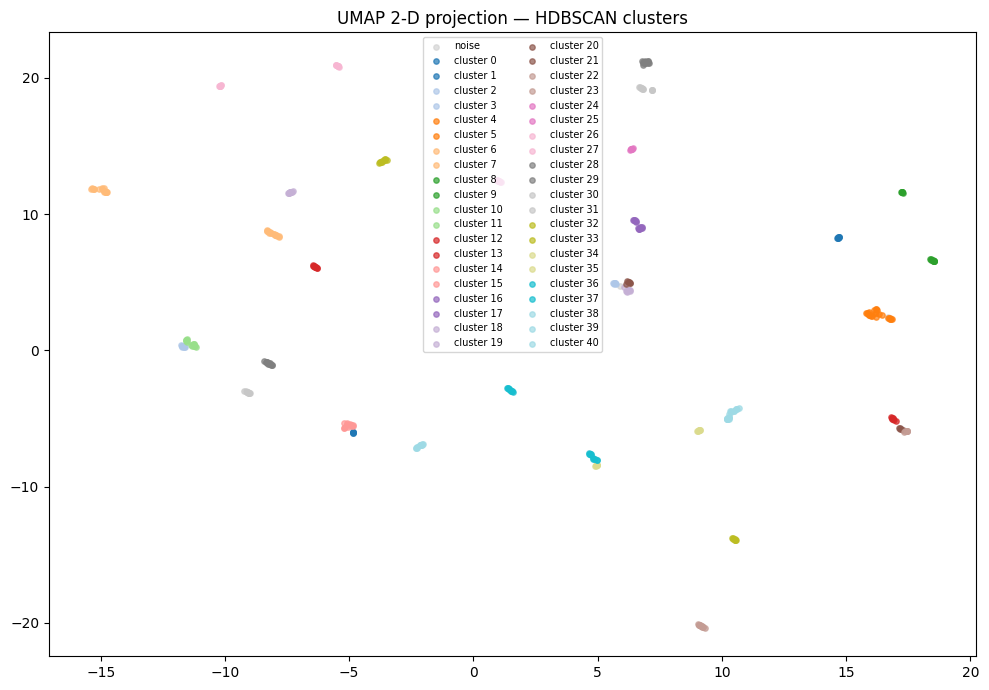

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
unique_labels = sorted(set(labels))
cmap = plt.get_cmap("tab20", len(unique_labels))

for i, lbl in enumerate(unique_labels):
    mask = labels == lbl
    color = "lightgrey" if lbl == -1 else cmap(i)
    label = "noise" if lbl == -1 else f"cluster {lbl}"
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=15, color=color, label=label, alpha=0.7)

ax.legend(loc="best", fontsize=7, ncol=2)
ax.set_title("UMAP 2-D projection — HDBSCAN clusters")
plt.tight_layout()
plt.show()

## 4 · Select Best Representatives per Cluster

Strategy: for each cluster take the **medoid** (closest point to the centroid in embedding space) as the primary representative, plus up to `TOP_K_MEMBERS - 1` additional points ranked by HDBSCAN membership probability.

In [22]:
TOP_K_MEMBERS = 8   # max representative interventions to feed to the LLM per cluster

def get_cluster_representatives(df_cluster: pd.DataFrame, cluster_embeddings: np.ndarray, top_k: int = 8):
    """Return df rows for the medoid + top-(top_k-1) by cluster_prob."""
    centroid = cluster_embeddings.mean(axis=0)
    dists = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    medoid_idx = int(np.argmin(dists))

    # Sort remaining by probability desc, take top_k-1
    rest = df_cluster.drop(index=df_cluster.index[medoid_idx])
    rest = rest.sort_values("cluster_prob", ascending=False).head(top_k - 1)

    medoid_row = df_cluster.iloc[[medoid_idx]]
    return pd.concat([medoid_row, rest], ignore_index=True)


cluster_representatives: dict[int, pd.DataFrame] = {}
for cid in sorted(set(labels)):
    if cid == -1:
        continue
    mask = (df["cluster"] == cid).values
    sub_df = df[mask].reset_index(drop=True)
    sub_emb = embeddings[mask]
    cluster_representatives[cid] = get_cluster_representatives(sub_df, sub_emb, top_k=TOP_K_MEMBERS)

print(f"Computed representatives for {len(cluster_representatives)} clusters.")
for cid, reps in cluster_representatives.items():
    print(f"  cluster {cid:2d} — {len(df[df.cluster == cid])} total, {len(reps)} reps")

Computed representatives for 41 clusters.
  cluster  0 — 5 total, 5 reps
  cluster  1 — 8 total, 8 reps
  cluster  2 — 7 total, 7 reps
  cluster  3 — 8 total, 8 reps
  cluster  4 — 7 total, 7 reps
  cluster  5 — 19 total, 8 reps
  cluster  6 — 18 total, 8 reps
  cluster  7 — 18 total, 8 reps
  cluster  8 — 7 total, 7 reps
  cluster  9 — 11 total, 8 reps
  cluster 10 — 6 total, 6 reps
  cluster 11 — 9 total, 8 reps
  cluster 12 — 9 total, 8 reps
  cluster 13 — 11 total, 8 reps
  cluster 14 — 9 total, 8 reps
  cluster 15 — 6 total, 6 reps
  cluster 16 — 7 total, 7 reps
  cluster 17 — 10 total, 8 reps
  cluster 18 — 12 total, 8 reps
  cluster 19 — 9 total, 8 reps
  cluster 20 — 7 total, 7 reps
  cluster 21 — 5 total, 5 reps
  cluster 22 — 7 total, 7 reps
  cluster 23 — 14 total, 8 reps
  cluster 24 — 8 total, 8 reps
  cluster 25 — 9 total, 8 reps
  cluster 26 — 9 total, 8 reps
  cluster 27 — 8 total, 8 reps
  cluster 28 — 14 total, 8 reps
  cluster 29 — 15 total, 8 reps
  cluster 30 — 13 

## 5 · LLM Structured Output — `KnownIssue` Template

In [23]:
class RootCauseAction(BaseModel):
    root_cause: str = Field(description="Normalized root cause name (specific, avoid generalist terms).")
    actions: list[str] = Field(description="Ordered list of corrective actions that resolved this root cause.")


class KnownIssue(BaseModel):
    symptom_name: str = Field(
        description=(
            "Normalized failure phenomenon name. "
            "NEVER include machine IDs or machine names — those belong in affected_machines. "
            "Good: 'Coil Cooling Flow Fault'. Bad: 'Coil Cooling Flow Fault – IH-300'. "
            "Calibrate specificity to cluster size: be more precise for small clusters."
        )
    )
    description: str = Field(description="2-4 sentence description of the issue pattern.")
    root_causes: list[RootCauseAction] = Field(
        description="Main root causes observed in this cluster, each with the actions that resolved them."
    )
    affected_machines: list[str] = Field(description="Normalized machine IDs impacted (e.g., ['CNC-500', 'CNC-750']).")
    affected_machine_families: list[str] = Field(
        description="Machine type/family names (e.g., ['CNC Machining Center'])."
    )
    representative_intervention_ids: list[str] = Field(
        description="INT-IDs of the most representative interventions for this issue."
    )

In [24]:
SYNTHESIS_SYSTEM_PROMPT = """\
You are a senior maintenance engineer synthesizing a knowledge base of known equipment issues.
Given a set of corrective-maintenance intervention records belonging to the same semantic cluster,
produce a single structured KnownIssue entry.

Rules:
- symptom_name must describe the failure phenomenon only — never include machine IDs, machine names,
  or location suffixes (e.g. write "Coil Cooling Flow Fault", NOT "Coil Cooling Flow Fault – IH-300").
  Machine scope belongs exclusively in affected_machines and affected_machine_families.
- symptom_name must be specific and equipment-class-scoped; avoid generic labels.
  Scale specificity to cluster size: a 5-record cluster warrants more precision than a 30-record one.
- List ALL root causes observed across the cluster, not just the most common one.
- Actions must be practical and ordered (first step first).
- Machines and families must be normalized (consistent casing, standard IDs).
- representative_intervention_ids should list only the most representative INT-IDs provided.
"""

def build_synthesis_user_message(reps: pd.DataFrame) -> str:
    lines = [f"Cluster size (total interventions): {len(reps)}\n", "--- Representative Interventions ---"]
    for _, row in reps.iterrows():
        lines.append(
            f"\nID: {row.get('id', 'N/A')}\n"
            f"Machine: {row.get('machine', 'N/A')}\n"
            f"Summary:\n{row.get('summary', '')}"
        )
    return "\n".join(lines)


def synthesize_known_issue(reps: pd.DataFrame, cluster_size: int) -> KnownIssue:
    user_msg = build_synthesis_user_message(reps)
    user_msg = f"Cluster size (total interventions): {cluster_size}\n" + user_msg[user_msg.find("---"):]

    response = client_oai.beta.chat.completions.parse(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": SYNTHESIS_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
        response_format=KnownIssue,
    )
    return response.choices[0].message.parsed

In [ ]:
known_issues: dict[int, KnownIssue] = {}

for cid, reps in cluster_representatives.items():
    cluster_size = int((df["cluster"] == cid).sum())
    print(f"Synthesizing cluster {cid} ({cluster_size} interventions) ...")
    issue = synthesize_known_issue(reps, cluster_size)
    known_issues[cid] = issue
    print(f"  → {issue.symptom_name}")

print(f"\nDone. {len(known_issues)} known issues synthesized.")

Synthesizing cluster 0 (5 interventions) ...
  → AGC Hydraulic Pressure Fault
Synthesizing cluster 1 (8 interventions) ...


In [ ]:
# Quick preview of the first synthesized issue
first_issue = known_issues[sorted(known_issues.keys())[0]]
print(first_issue.model_dump_json(indent=2))

## 6 · Store Known Issues in Qdrant

Each `KnownIssue` is embedded (via its `symptom_name + description`) and stored as a point in
the `known_issues` collection. The full structured data lives in the payload.

In [ ]:
EMBEDDING_SIZE = 1536  # text-embedding-3-small

def recreate_known_issues_collection(client: QdrantClient, name: str):
    if client.collection_exists(name):
        print(f"Dropping existing '{name}' collection ...")
        client.delete_collection(name)
    client.create_collection(
        collection_name=name,
        vectors_config=VectorParams(size=EMBEDDING_SIZE, distance=Distance.COSINE),
    )
    print(f"Created '{name}' collection.")


recreate_known_issues_collection(qdrant, KNOWN_ISSUES_COLLECTION)

In [ ]:
def embed_known_issue(issue: KnownIssue) -> list[float]:
    """Embed the symptom name + description as the issue's semantic anchor."""
    text = f"{issue.symptom_name}\n{issue.description}"
    resp = client_oai.embeddings.create(input=text, model=EMBEDDING_MODEL)
    return resp.data[0].embedding


def upsert_known_issues(client: QdrantClient, issues: dict[int, KnownIssue], collection: str):
    """
    Full-load upsert. Called after recreate_known_issues_collection, so every point is new.
    created_at is set once here and never overwritten by subsequent incremental updates.
    """
    points = []
    for cid, issue in issues.items():
        vec = embed_known_issue(issue)
        now = pd.Timestamp.now().isoformat()
        payload = issue.model_dump()
        payload["version"] = 1
        payload["created_at"] = now   # set once at birth — incremental path preserves this
        payload["updated_at"] = now
        points.append(PointStruct(id=str(uuid.uuid4()), vector=vec, payload=payload))
    client.upsert(collection_name=collection, points=points)
    print(f"Upserted {len(points)} known issues into '{collection}'.")
    return points


stored_points = upsert_known_issues(qdrant, known_issues, KNOWN_ISSUES_COLLECTION)

In [ ]:
# Verify stored content
stored, _ = qdrant.scroll(collection_name=KNOWN_ISSUES_COLLECTION, limit=50, with_payload=True, with_vectors=False)
print(f"Total known issues stored: {len(stored)}")
for p in stored:
    print(f"  [{p.payload['symptom_name']}")

## 7 · Evolutive Update — Integrate New Batches

When new corrective-maintenance interventions arrive:
1. Embed them.
2. Search `known_issues` by cosine similarity.
3. If best match ≥ `SIMILARITY_THRESHOLD` → ask the LLM whether to **merge** or keep separate.
4. If merge → re-synthesize the updated issue and upsert with `version += 1`.
5. Otherwise → synthesize a brand-new `KnownIssue` and append.

In [ ]:
class MergeDecision(BaseModel):
    should_merge: bool = Field(
        description="True if the new interventions belong to the same issue pattern as the candidate."
    )
    rationale: str = Field(description="One-sentence justification for the merge/no-merge decision.")


MERGE_SYSTEM_PROMPT = """\
You are a maintenance knowledge engineer.
Decide whether new maintenance interventions belong to an existing known issue pattern.
Respond with should_merge=true only if the symptom, affected subsystem, and failure mechanisms
are clearly the same. Minor root-cause variations within the same phenomenon are acceptable.
"""

def decide_merge(new_summaries: list[str], existing_issue: KnownIssue) -> MergeDecision:
    user_msg = (
        f"Existing known issue:\n{existing_issue.model_dump_json(indent=2)}\n\n"
        f"New interventions to classify:\n"
        + "\n---\n".join(new_summaries)
    )
    response = client_oai.beta.chat.completions.parse(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": MERGE_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
        response_format=MergeDecision,
    )
    return response.choices[0].message.parsed

In [ ]:
def embed_texts(texts: list[str]) -> list[list[float]]:
    resp = client_oai.embeddings.create(input=texts, model=EMBEDDING_MODEL)
    return [e.embedding for e in resp.data]


def find_best_matching_issue(client: QdrantClient, collection: str, embedding: list[float], top_k: int = 1):
    """Return (point_id, score, payload) of the best matching known issue, or None."""
    hits = client.search(
        collection_name=collection,
        query_vector=embedding,
        limit=top_k,
        with_payload=True,
    )
    return hits[0] if hits else None


def load_known_issue_payload(payload: dict) -> KnownIssue:
    return KnownIssue(**{k: v for k, v in payload.items() if k in KnownIssue.model_fields})


def process_new_batch(
    new_records: list[dict],   # list of {"id": ..., "summary": ..., "machine": ...}
    client: QdrantClient,
    source_collection: str,
    known_issues_collection: str,
    similarity_threshold: float = SIMILARITY_THRESHOLD,
    dry_run: bool = False,
) -> list[dict]:
    """
    Process a new batch of intervention records and update the known_issues collection.
    Returns a log of actions taken.
    """
    summaries = [r["summary"] for r in new_records]
    new_embeddings = embed_texts(summaries)

    # Centroid embedding to search for the closest known issue
    centroid = np.mean(new_embeddings, axis=0).tolist()
    best_match = find_best_matching_issue(client, known_issues_collection, centroid)

    log = []

    if best_match is not None and best_match.score >= similarity_threshold:
        existing_issue = load_known_issue_payload(best_match.payload)
        print(f"Best match: '{existing_issue.symptom_name}' (score={best_match.score:.3f})")

        decision = decide_merge(summaries, existing_issue)
        print(f"Merge decision: {decision.should_merge} — {decision.rationale}")

        if decision.should_merge:
            # Build merged representative set and re-synthesize
            existing_int_ids = existing_issue.representative_intervention_ids
            new_rows = pd.DataFrame(new_records)
            new_rows["cluster_prob"] = 1.0  # treat all new as high-confidence
            merged_reps = new_rows.head(TOP_K_MEMBERS)
            merged_cluster_size = len(new_records) + len(existing_int_ids)

            updated_issue = synthesize_known_issue(merged_reps, merged_cluster_size)
            # Preserve existing representative IDs + add new ones
            updated_issue.representative_intervention_ids = list(
                dict.fromkeys(existing_int_ids + [r["id"] for r in new_records])
            )[:TOP_K_MEMBERS]

            if not dry_run:
                new_vec = embed_known_issue(updated_issue)
                new_version = best_match.payload.get("version", 1) + 1
                updated_payload = updated_issue.model_dump()
                updated_payload["cluster_id"] = best_match.payload.get("cluster_id", -1)
                updated_payload["version"] = new_version
                updated_payload["created_at"] = best_match.payload.get("created_at")
                updated_payload["updated_at"] = pd.Timestamp.now().isoformat()
                client.upsert(
                    collection_name=known_issues_collection,
                    points=[PointStruct(id=best_match.id, vector=new_vec, payload=updated_payload)],
                )
                print(f"Updated existing issue to version {new_version}: '{updated_issue.symptom_name}'")

            log.append({"action": "merged", "symptom_name": updated_issue.symptom_name, "matched_issue_id": best_match.id})
            return log

    # No match or merge rejected → create new known issue
    print("No suitable existing issue found. Creating a new KnownIssue...")
    new_rows = pd.DataFrame(new_records)
    new_rows["cluster_prob"] = 1.0
    new_issue = synthesize_known_issue(new_rows.head(TOP_K_MEMBERS), len(new_records))

    if not dry_run:
        vec = embed_known_issue(new_issue)
        payload = new_issue.model_dump()
        payload["cluster_id"] = -2  # synthetic new cluster
        payload["version"] = 1
        payload["created_at"] = pd.Timestamp.now().isoformat()
        client.upsert(
            collection_name=known_issues_collection,
            points=[PointStruct(id=str(uuid.uuid4()), vector=vec, payload=payload)],
        )
        print(f"New known issue created: '{new_issue.symptom_name}'")

    log.append({"action": "created", "symptom_name": new_issue.symptom_name})
    return log

### 7.1 · Demo: Simulate a New Batch

Pick a few known interventions to simulate a realistic new batch.

In [ ]:
# Simulate a new batch: take 3 interventions from the source df that are NOT already top representatives
# In production, replace this with actual new records from the CSV or another data source.
sample_batch = (
    df[df["cluster"] != -1]
    .sample(n=4, random_state=99)
    [["id", "summary", "machine"]]
    .to_dict(orient="records")
)
print("Simulated new batch:")
for r in sample_batch:
    print(f"  {r['id']} | {r['machine']}")

In [ ]:
action_log = process_new_batch(
    new_records=sample_batch,
    client=qdrant,
    source_collection=SOURCE_COLLECTION,
    known_issues_collection=KNOWN_ISSUES_COLLECTION,
    dry_run=False,  # set True to inspect without writing
)
print("\nAction log:", action_log)

## 8 · Inspect the Final Known Issues Collection

In [ ]:
all_issues, _ = qdrant.scroll(
    collection_name=KNOWN_ISSUES_COLLECTION,
    limit=100,
    with_payload=True,
    with_vectors=False,
)

rows = []
for p in all_issues:
    pl = p.payload
    rows.append({
        "id": p.id,
        "version": pl.get("version"),
        "symptom_name": pl.get("symptom_name"),
        "affected_machines": ", ".join(pl.get("affected_machines", [])),
        "affected_families": ", ".join(pl.get("affected_machine_families", [])),
        "n_root_causes": len(pl.get("root_causes", [])),
        "n_rep_ids": len(pl.get("representative_intervention_ids", [])),
    })

pd.DataFrame(rows)

,id,version,symptom_name,affected_machines,affected_families,n_root_causes,n_rep_ids
0,03be7ae7-fcd6-456f-a637-9aa0845a9551,1,Rotary Table Encoder Fault,CNC-750,CNC Machining Center,1,3
1,05728af7-53ae-4ede-9742-be0a00acc25e,1,Axis Hydraulic Clamp Fault,CNC-750,CNC Machining Center,1,3
2,0603baf3-797b-4e9c-ba18-176b532b65ee,1,Coolant Emulsion Out of Range,CR-150,Coolant Recycling System,2,3
3,0fd4ecfd-28a8-4d89-b8e3-3bc48ffd98fc,1,Axis Hydraulic Clamp Fault,CNC-750,CNC Machining Center,2,5
4,12100b19-d07c-4b47-940a-d025c98092ef,1,Return Pump Fault,HX-350,Heat Exchanger,1,3
5,136ae97a-70db-4c04-87e0-841c2d3bad28,1,Lubrication Flow Low,CR-100,Lubrication System,1,3
6,1ecd7e31-e175-4c02-9667-7a18b20dc499,1,Vision System Calibration Drift,AS-600,Automated Systems,1,3
7,2e69a1ea-2ed7-41f6-9e00-d61147e1b363,1,Temperature Compensation Fault,CM-80,Temperature Control Systems,1,3
8,31cd4769-b8ae-4457-9644-44f3a342529e,1,Lubrication Flow Low,CR-100,Lubrication Systems,1,3
9,31f598ea-e4c5-4f88-ba44-c5ff392f1ddb,1,Drive Motor Overtemperature,CB-200,Conveyor System,3,3


## 9 · Knowledge Graph from Known Issues

Build an in-memory `networkx` graph from the `known_issues` Qdrant collection.
The graph is **reconstructed on demand** — no extra database needed.

### Node types
| Prefix | Meaning |
|--------|---------|
| `ISSUE:` | A synthesized `KnownIssue` |
| `RC:` | A normalized root cause |
| `ACTION:` | A corrective action |
| `MACHINE:` | A specific machine ID |
| `FAMILY:` | A machine family/type |

### Edge types
| Edge | Meaning |
|------|---------|
| `ISSUE → RC` | `caused_by` |
| `RC → ACTION` | `resolved_by` |
| `ISSUE → MACHINE` | `affects` |
| `MACHINE → FAMILY` | `belongs_to` |
| `ISSUE → ISSUE` | `shares_root_cause` (derived) |

In [ ]:
import networkx as nx

def build_knowledge_graph(issues: list) -> nx.DiGraph:
    """Build a directed knowledge graph from Qdrant known_issues points.

    Node types : issue, symptom, root_cause, action, machine, family, intervention
    Edge types : manifests_as, caused_by, resolved_by, affects, belongs_to,
                 has_representative, shares_symptom (derived), shares_root_cause (derived)
    """
    G = nx.DiGraph()

    for point in issues:
        pl = point.payload

        issue_node = f"ISSUE:{pl['symptom_name']}"
        G.add_node(issue_node, type="issue", cluster_id=pl.get("cluster_id"), version=pl.get("version", 1))

        # Symptom as a first-class node
        symptom_node = f"SYMPTOM:{pl['symptom_name']}"
        G.add_node(symptom_node, type="symptom")
        G.add_edge(issue_node, symptom_node, relation="manifests_as")

        # Root causes → actions
        for rc_obj in pl.get("root_causes", []):
            rc_node = f"RC:{rc_obj['root_cause']}"
            G.add_node(rc_node, type="root_cause")
            G.add_edge(issue_node, rc_node, relation="caused_by")

            for i, action in enumerate(rc_obj.get("actions", [])):
                action_node = f"ACTION:{action}"
                G.add_node(action_node, type="action")
                G.add_edge(rc_node, action_node, relation="resolved_by", order=i)

        # Machines → families
        for machine in pl.get("affected_machines", []):
            m_node = f"MACHINE:{machine}"
            G.add_node(m_node, type="machine")
            G.add_edge(issue_node, m_node, relation="affects")

        for family in pl.get("affected_machine_families", []):
            f_node = f"FAMILY:{family}"
            G.add_node(f_node, type="family")
            for machine in pl.get("affected_machines", []):
                G.add_edge(f"MACHINE:{machine}", f_node, relation="belongs_to")

        # Representative intervention IDs
        for int_id in pl.get("representative_intervention_ids", []):
            int_node = f"INT:{int_id}"
            G.add_node(int_node, type="intervention")
            G.add_edge(issue_node, int_node, relation="has_representative")

    # Derived: ISSUE --shares_root_cause--> ISSUE
    issue_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "issue"]
    rc_to_issues: dict[str, list[str]] = {}
    for issue in issue_nodes:
        for _, rc, data in G.out_edges(issue, data=True):
            if data.get("relation") == "caused_by":
                rc_to_issues.setdefault(rc, []).append(issue)
    for rc, linked_issues in rc_to_issues.items():
        for i in range(len(linked_issues)):
            for j in range(i + 1, len(linked_issues)):
                G.add_edge(linked_issues[i], linked_issues[j], relation="shares_root_cause", via=rc)
                G.add_edge(linked_issues[j], linked_issues[i], relation="shares_root_cause", via=rc)

    # Derived: ISSUE --shares_symptom--> ISSUE
    symptom_to_issues: dict[str, list[str]] = {}
    for issue in issue_nodes:
        for _, sym, data in G.out_edges(issue, data=True):
            if data.get("relation") == "manifests_as":
                symptom_to_issues.setdefault(sym, []).append(issue)
    for sym, linked_issues in symptom_to_issues.items():
        for i in range(len(linked_issues)):
            for j in range(i + 1, len(linked_issues)):
                G.add_edge(linked_issues[i], linked_issues[j], relation="shares_symptom", via=sym)
                G.add_edge(linked_issues[j], linked_issues[i], relation="shares_symptom", via=sym)

    return G


G = build_knowledge_graph(all_issues)

node_counts = {}
for _, data in G.nodes(data=True):
    t = data.get("type", "unknown")
    node_counts[t] = node_counts.get(t, 0) + 1

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
for t, c in sorted(node_counts.items()):
    print(f"  {t:12s}: {c}")

Graph: 484 nodes, 492 edges
  action      : 189
  family      : 25
  intervention: 150
  issue       : 24
  machine     : 10
  root_cause  : 62
  symptom     : 24


### 9.1 · Useful Graph Queries

In [ ]:
# Q1 — Which root causes appear in the most known issues? (cross-issue hotspots)
rc_nodes = [(n, G.in_degree(n)) for n, d in G.nodes(data=True) if d.get("type") == "root_cause"]
rc_df = pd.DataFrame(rc_nodes, columns=["root_cause", "n_issues"]).sort_values("n_issues", ascending=False)
rc_df["root_cause"] = rc_df["root_cause"].str.replace("RC:", "", regex=False)
print("Top root causes by number of known issues affected:")
print(rc_df.head(10).to_string(index=False))

Top root causes by number of known issues affected:
              root_cause  n_issues
          Hydraulic Leak         2
               Pump Wear         2
            Cable Damage         1
           Low Oil Level         1
    Spindle Misalignment         1
Sensor Calibration Drift         1
  Cooling Valve Sticking         1
    Servo Valve Sticking         1
      Contaminated Spool         1
       Pump Bearing Wear         1


In [ ]:
# Q2 — Which machines are affected by the most distinct known issues?
machine_nodes = [
    (n.replace("MACHINE:", ""), G.in_degree(n))
    for n, d in G.nodes(data=True) if d.get("type") == "machine"
]
m_df = pd.DataFrame(machine_nodes, columns=["machine", "n_issues"]).sort_values("n_issues", ascending=False)
print("Machines by number of known issues:")
print(m_df.to_string(index=False))

Machines by number of known issues:
machine  n_issues
 HX-200         4
  CM-80         3
 CB-200         3
 IH-300         3
CNC-750         2
 CR-150         2
 HX-350         2
 CR-100         2
CNC-500         2
 AS-600         1


In [ ]:
# Q3 — Given a machine, what are all reachable root causes (1 hop via issue)?
def root_causes_for_machine(G: nx.DiGraph, machine_id: str) -> list[str]:
    m_node = f"MACHINE:{machine_id}"
    if m_node not in G:
        return []
    issues = [src for src, _, d in G.in_edges(m_node, data=True) if d.get("relation") == "affects"]
    rcs = set()
    for issue in issues:
        for _, rc, d in G.out_edges(issue, data=True):
            if d.get("relation") == "caused_by":
                rcs.add(rc.replace("RC:", ""))
    return sorted(rcs)


sample_machine = m_df.iloc[0]["machine"]
rcs = root_causes_for_machine(G, sample_machine)
print(f"Root causes for {sample_machine}:")
for rc in rcs:
    print(f"  - {rc}")

Root causes for HX-200:
  - Clogged Suction Filter
  - Coil Burnout
  - Contaminated Spool
  - Cooler Fouling
  - Fan Failure
  - Hydraulic Leak
  - Loose Wiring
  - Low Oil Level
  - Pump Wear


In [ ]:
# Q4 — Given a machine, what are all recommended actions (machine → issue → RC → action)?
def actions_for_machine(G: nx.DiGraph, machine_id: str) -> list[dict]:
    m_node = f"MACHINE:{machine_id}"
    if m_node not in G:
        return []
    issues = [src for src, _, d in G.in_edges(m_node, data=True) if d.get("relation") == "affects"]
    results = []
    for issue in issues:
        for _, rc, d in G.out_edges(issue, data=True):
            if d.get("relation") != "caused_by":
                continue
            for _, action, ad in G.out_edges(rc, data=True):
                if ad.get("relation") == "resolved_by":
                    results.append({
                        "issue": issue.replace("ISSUE:", ""),
                        "root_cause": rc.replace("RC:", ""),
                        "action": action.replace("ACTION:", ""),
                        "order": ad.get("order", 0),
                    })
    return sorted(results, key=lambda x: (x["root_cause"], x["order"]))


actions = actions_for_machine(G, sample_machine)
print(f"Recommended actions for {sample_machine}:")
pd.DataFrame(actions)

Recommended actions for HX-200:


,issue,root_cause,action,order
0,Low Hydraulic Pressure,Clogged Suction Filter,Inspect and clean the suction filter regularly,0
1,Low Hydraulic Pressure,Clogged Suction Filter,Replace the suction filter if cleaning is insu...,1
2,Solenoid Valve No Response,Coil Burnout,Replace burnt solenoid coil.,0
3,Solenoid Valve No Response,Coil Burnout,Perform functional tests to ensure proper oper...,1
4,Solenoid Valve No Response,Contaminated Spool,Clean or replace contaminated valve spool.,0
5,Solenoid Valve No Response,Contaminated Spool,Perform functional tests to ensure proper oper...,1
6,High Oil Temperature Fault,Cooler Fouling,Inspect oil cooler for fouling,0
7,High Oil Temperature Fault,Cooler Fouling,Clean or replace oil cooler as necessary,1
8,High Oil Temperature Fault,Cooler Fouling,Perform functional test,2
9,High Oil Temperature Fault,Fan Failure,Inspect fan operation,0


In [ ]:
# Q5 — Which pairs of known issues share root causes? (cross-contamination / related failure modes)
shared_rc_edges = [
    (u.replace("ISSUE:", ""), v.replace("ISSUE:", ""), d["via"].replace("RC:", ""))
    for u, v, d in G.edges(data=True)
    if d.get("relation") == "shares_root_cause" and u < v  # deduplicate symmetric pairs
]
shared_df = pd.DataFrame(shared_rc_edges, columns=["issue_a", "issue_b", "shared_root_cause"])
print(f"{len(shared_df)} issue-pairs share at least one root cause:")
shared_df

2 issue-pairs share at least one root cause:


,issue_a,issue_b,shared_root_cause
0,AGC Hydraulic Pressure Fault,Low Hydraulic Pressure,Hydraulic Leak
1,Low Hydraulic Pressure,Lubrication Flow Low,Pump Wear


### 9.2 · Graph Visualisation

Two options:
- **Static** (matplotlib) — quick overview, readable only for small subgraphs
- **Interactive** (pyvis HTML) — zoomable, draggable, hover tooltips, full graph with all node types

The pyvis cell renders `data/known_issues_graph.html` and opens it in the browser.

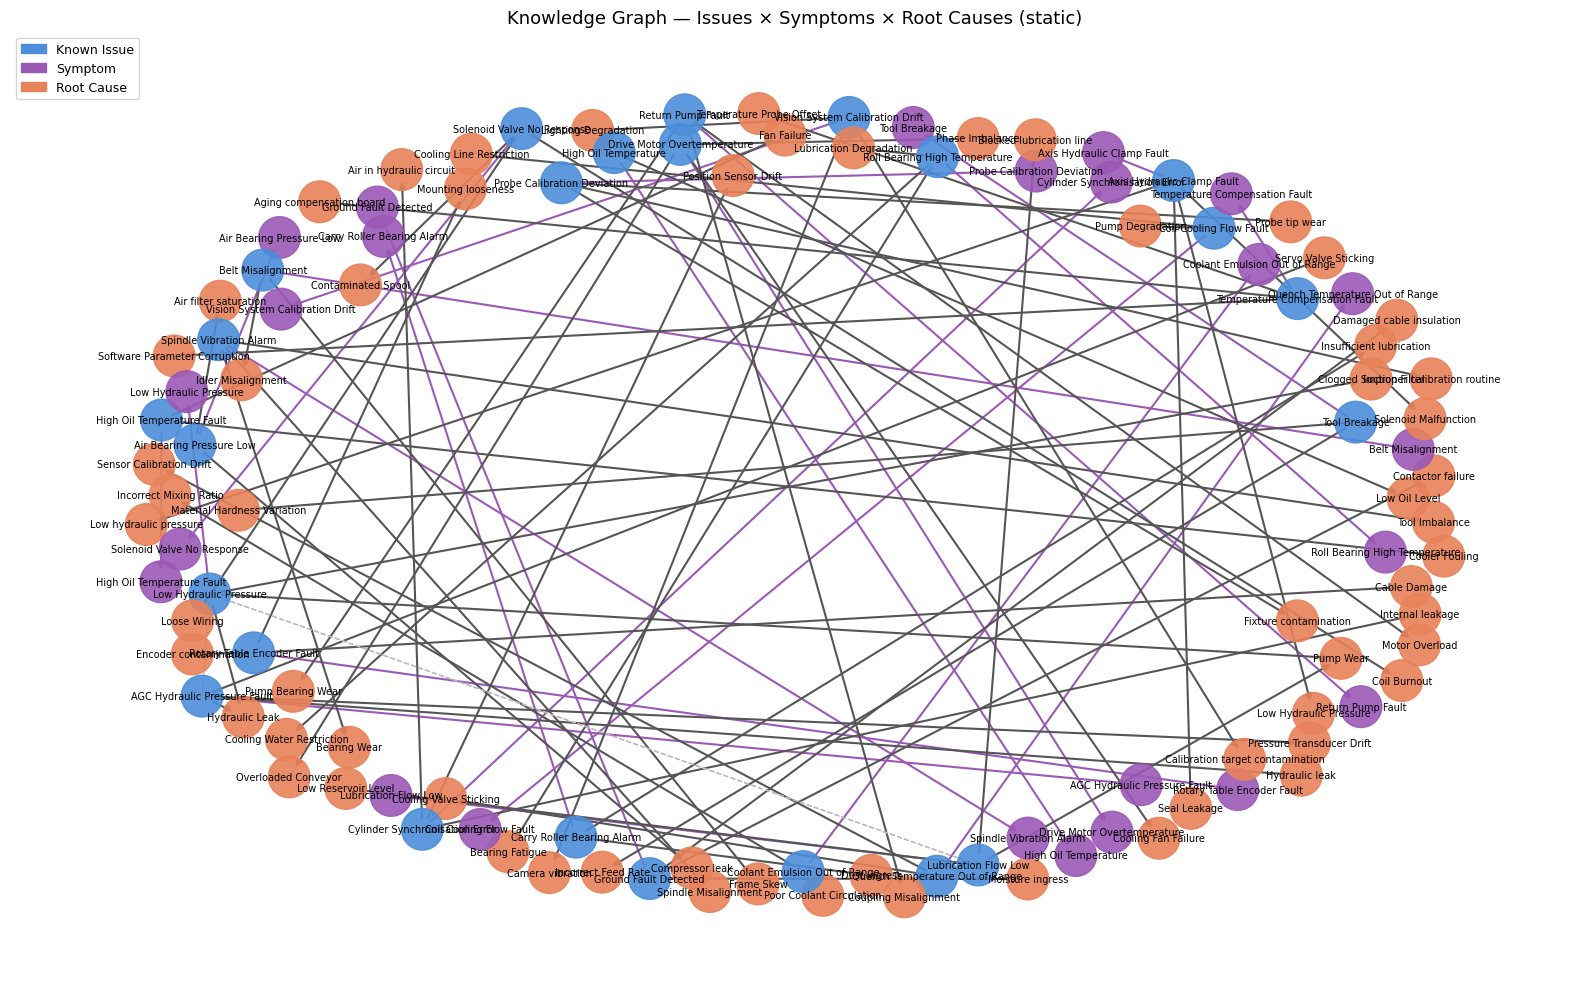

In [ ]:
from matplotlib.patches import Patch

# Static matplotlib view — Issue × Symptom × Root Cause subgraph only
def draw_issue_rc_graph(G: nx.DiGraph):
    keep_relations = {"manifests_as", "caused_by", "shares_root_cause", "shares_symptom"}
    keep_types = {"issue", "symptom", "root_cause"}
    sub_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("relation") in keep_relations
        and G.nodes[u].get("type") in keep_types
        and G.nodes[v].get("type") in keep_types
    ]
    H = G.edge_subgraph(sub_edges).copy()

    type_color = {"issue": "#4C8EDA", "symptom": "#9B59B6", "root_cause": "#E8825A"}
    node_colors = [type_color.get(G.nodes[n].get("type"), "#cccccc") for n in H.nodes()]

    labels = {}
    for n in H.nodes():
        raw = n.split(":", 1)[1] if ":" in n else n
        labels[n] = (raw[:38] + "…") if len(raw) > 38 else raw

    pos = nx.spring_layout(H, seed=42, k=2.5)
    fig, ax = plt.subplots(figsize=(16, 10))
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=900, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=7, ax=ax)

    manifests_edges = [(u, v) for u, v, d in H.edges(data=True) if d.get("relation") == "manifests_as"]
    caused_by_edges = [(u, v) for u, v, d in H.edges(data=True) if d.get("relation") == "caused_by"]
    shared_rc_edges = [(u, v) for u, v, d in H.edges(data=True) if d.get("relation") == "shares_root_cause"]
    shared_sym_edges = [(u, v) for u, v, d in H.edges(data=True) if d.get("relation") == "shares_symptom"]

    nx.draw_networkx_edges(H, pos, edgelist=manifests_edges, edge_color="#9B59B6", arrows=True, ax=ax, width=1.5)
    nx.draw_networkx_edges(H, pos, edgelist=caused_by_edges, edge_color="#555", arrows=True, ax=ax, width=1.5)
    nx.draw_networkx_edges(H, pos, edgelist=shared_rc_edges, edge_color="#bbb", style="dashed", arrows=False, ax=ax)
    nx.draw_networkx_edges(H, pos, edgelist=shared_sym_edges, edge_color="#d7a8f0", style="dotted", arrows=False, ax=ax)

    ax.legend(handles=[
        Patch(color="#4C8EDA", label="Known Issue"),
        Patch(color="#9B59B6", label="Symptom"),
        Patch(color="#E8825A", label="Root Cause"),
    ], loc="upper left", fontsize=9)
    ax.set_title("Knowledge Graph — Issues × Symptoms × Root Causes (static)", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_issue_rc_graph(G)

In [ ]:
import webbrowser
from pyvis.network import Network

# Node type → (hex color, size)
NODE_STYLE: dict[str, tuple[str, int]] = {
    "issue":         ("#4C8EDA", 30),
    "symptom":       ("#9B59B6", 22),
    "root_cause":    ("#E8825A", 20),
    "action":        ("#2ECC71", 16),
    "machine":       ("#F5C842", 18),
    "family":        ("#E74C3C", 22),
    "intervention":  ("#A0A0A0", 12),   # small grey — evidence trail
}

# Edge relation → color
EDGE_STYLE: dict[str, str] = {
    "manifests_as":      "#9B59B6",
    "caused_by":         "#E8825A",
    "resolved_by":       "#2ECC71",
    "affects":           "#F5C842",
    "belongs_to":        "#E74C3C",
    "has_representative": "#A0A0A0",
    "shares_root_cause": "#bbbbbb",
    "shares_symptom":    "#d7a8f0",
}

# Derived edges are hidden by default — too noisy in full view
HIDDEN_RELATIONS = {"shares_root_cause", "shares_symptom"}


def build_pyvis_graph(G: nx.DiGraph, output_path: str = "../data/known_issues_graph.html"):
    net = Network(height="920px", width="100%", directed=True, bgcolor="#1a1a2e", font_color="white")
    net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150, spring_strength=0.05)

    for node, data in G.nodes(data=True):
        ntype = data.get("type", "unknown")
        color, size = NODE_STYLE.get(ntype, ("#cccccc", 14))
        label = node.split(":", 1)[1] if ":" in node else node
        short_label = (label[:35] + "…") if len(label) > 35 else label

        tooltip_lines = [f"<b>{short_label}</b>", f"Type: {ntype}"]
        if ntype == "issue":
            tooltip_lines.append(f"Cluster: {data.get('cluster_id', '?')}")
            tooltip_lines.append(f"Version: {data.get('version', 1)}")

        # Intervention nodes: use a square shape to visually distinguish them
        shape = "square" if ntype == "intervention" else "dot"

        net.add_node(
            node,
            label=short_label,
            title="<br>".join(tooltip_lines),
            color=color,
            size=size,
            shape=shape,
        )

    for u, v, data in G.edges(data=True):
        relation = data.get("relation", "")
        if relation in HIDDEN_RELATIONS:
            continue
        color = EDGE_STYLE.get(relation, "#888888")
        # Intervention edges are thinner and dashed to avoid visual clutter
        dashes = relation == "has_representative"
        net.add_edge(u, v, title=relation, color=color, arrows="to",
                     width=1.0 if dashes else 1.5, dashes=dashes)

    net.write_html(output_path)
    print(f"Interactive graph saved → {output_path}")
    return output_path


html_path = build_pyvis_graph(G)
webbrowser.open(f"file://{Path(html_path).resolve()}")

Interactive graph saved → ../data/known_issues_graph.html


True

### 9.3 · Export the Graph

Serialise to JSON (node-link format) so the RCA agent can load it at startup without rebuilding from Qdrant every time.

In [ ]:
import json

graph_path = Path("../data/known_issues_graph.json")
data = nx.node_link_data(G)
graph_path.write_text(json.dumps(data, indent=2))
print(f"Graph saved to {graph_path}  ({graph_path.stat().st_size / 1024:.1f} KB)")

# Round-trip check
G_loaded = nx.node_link_graph(json.loads(graph_path.read_text()))
print(f"Loaded: {G_loaded.number_of_nodes()} nodes, {G_loaded.number_of_edges()} edges")

Graph saved to ../data/known_issues_graph.json  (116.7 KB)
Loaded: 484 nodes, 492 edges
